In [1]:
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"


In [2]:
# Cell 1: Imports
import os
from pathlib import Path
import random
import numpy as np
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, datasets

import timm
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


In [3]:
# Cell 2: Reproducibility & Device
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cpu


In [4]:
# Cell 3: Safe Loader (prevents crashes on truncated images)
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
# Optionally increase PIL max image pixels (if you get DecompressionBombError)
Image.MAX_IMAGE_PIXELS = None


In [5]:
# Cell 4: Paths & Hyperparameters
# <-- EDIT this to match your system if needed -->
THERMAL_ROOT = Path(r"C:\Users\Madesh\OneDrive\Desktop\BEU\deep_mri\Thermal")

# Folders inside THERMAL_ROOT: Train, Test (case-sensitive as present on disk)
TRAIN_FOLDER = THERMAL_ROOT / "Train"
TEST_FOLDER  = THERMAL_ROOT / "Test"

IMG_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 4  # lower to 0 if running on Windows in debugging
EPOCHS = 10      # set 5 or 6 per your note
LR = 3e-5
WEIGHT_DECAY = 1e-2
NUM_CLASSES = 2   # stroke vs normal
MODEL_SAVE_PATH = Path("best_swin_thermal.pth")

print("Train folder exists:", TRAIN_FOLDER.exists())
print("Test folder exists:", TEST_FOLDER.exists())


Train folder exists: True
Test folder exists: True


In [6]:
# Cell 5: Datasets & Transforms
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Use ImageFolder assuming folder layout: Train/<class>/* , Test/<class>/*
train_dataset = datasets.ImageFolder(root=str(TRAIN_FOLDER), transform=train_transform)
val_dataset   = datasets.ImageFolder(root=str(TEST_FOLDER),  transform=val_transform)

print("Class to index mapping:", train_dataset.class_to_idx)
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


Class to index mapping: {'normal': 0, 'stroke': 1}
Train samples: 2335
Val samples: 775


In [7]:
# Cell 6: Swin Transformer model
model_name = "swin_tiny_patch4_window7_224"  # small & faster
model = timm.create_model(model_name, pretrained=True)

# Replace classification head
if hasattr(model, 'head'):
    in_features = model.head.in_features
    model.head = nn.Linear(in_features, NUM_CLASSES)
elif hasattr(model, 'fc'):
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, NUM_CLASSES)
else:
    raise RuntimeError("Unexpected model head structure; inspect the timm model")

model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Scheduler (no verbose needed)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=2
)


In [8]:
# Cell 7: Training Loop
best_val_acc = 0.0
train_history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    preds_all = []
    labels_all = []

    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch} - train"):
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE).long().view(-1)   # make sure labels are [batch]

        optimizer.zero_grad()
        outputs = model(imgs)

        # ✅ Flatten extra dimensions if model outputs [B, C, 1, 1]
        outputs = outputs.view(outputs.size(0), -1)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1).cpu().numpy()
        preds_all.extend(preds)
        labels_all.extend(labels.cpu().numpy())

    epoch_loss = running_loss / max(1, len(train_dataset))
    epoch_acc = accuracy_score(labels_all, preds_all) if len(labels_all) else 0.0
    train_history["train_loss"].append(epoch_loss)
    train_history["train_acc"].append(epoch_acc)

    # Validation
    model.eval()
    v_running_loss = 0.0
    v_preds = []
    v_labels = []
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(DEVICE)
            labels = labels.to(DEVICE).long().view(-1)
            outputs = model(imgs)

            # ✅ Flatten for validation too
            outputs = outputs.view(outputs.size(0), -1)

            loss = criterion(outputs, labels)
            v_running_loss += loss.item() * imgs.size(0)
            v_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            v_labels.extend(labels.cpu().numpy())

    val_loss = v_running_loss / max(1, len(val_dataset))
    val_acc = accuracy_score(v_labels, v_preds) if len(v_labels) else 0.0
    train_history["val_loss"].append(val_loss)
    train_history["val_acc"].append(val_acc)

    print(f"Epoch {epoch}/{EPOCHS} -> Train Loss: {epoch_loss:.4f} Train Acc: {epoch_acc:.4f} | Val Loss: {val_loss:.4f} Val Acc: {val_acc:.4f}")

    # Scheduler step
    scheduler.step(val_acc)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "epoch": epoch,
            "val_acc": val_acc
        }, MODEL_SAVE_PATH)
        print(f"Saved best model (val_acc={val_acc:.4f}) to {MODEL_SAVE_PATH}")


Epoch 1 - train: 100%|███████████████████████████████████████████████████████████████| 146/146 [08:41<00:00,  3.58s/it]


Epoch 1/10 -> Train Loss: 0.7365 Train Acc: 0.7842 | Val Loss: 0.1884 Val Acc: 0.9187
Saved best model (val_acc=0.9187) to best_swin_thermal.pth


Epoch 2 - train: 100%|███████████████████████████████████████████████████████████████| 146/146 [08:33<00:00,  3.51s/it]


Epoch 2/10 -> Train Loss: 0.2037 Train Acc: 0.9135 | Val Loss: 0.1337 Val Acc: 0.9497
Saved best model (val_acc=0.9497) to best_swin_thermal.pth


Epoch 3 - train: 100%|███████████████████████████████████████████████████████████████| 146/146 [08:30<00:00,  3.50s/it]


...

Epoch 8/10 -> Train Loss: 0.1012 Train Acc: 0.9640 | Val Loss: 0.1032 Val Acc: 0.9665


Epoch 9 - train: 100%|███████████████████████████████████████████████████████████████| 146/146 [08:34<00:00,  3.53s/it]


Epoch 9/10 -> Train Loss: 0.0614 Train Acc: 0.9764 | Val Loss: 0.0740 Val Acc: 0.9768
Saved best model (val_acc=0.9768) to best_swin_thermal.pth


Epoch 10 - train: 100%|██████████████████████████████████████████████████████████████| 146/146 [12:01<00:00,  4.94s/it]


Epoch 10/10 -> Train Loss: 0.0662 Train Acc: 0.9799 | Val Loss: 0.0895 Val Acc: 0.9716


Loaded best model from: best_swin_thermal.pth


Evaluating: 100%|██████████████████████████████████████████████████████████████████████| 49/49 [01:45<00:00,  2.14s/it]



Classification Report:
              precision    recall  f1-score   support

      normal       0.96      0.99      0.97       335
      stroke       0.99      0.97      0.98       440

    accuracy                           0.98       775
   macro avg       0.98      0.98      0.98       775
weighted avg       0.98      0.98      0.98       775

Overall Accuracy: 0.9767741935483871


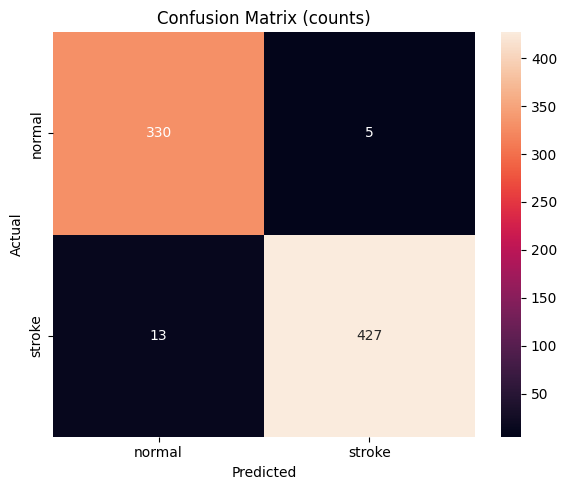

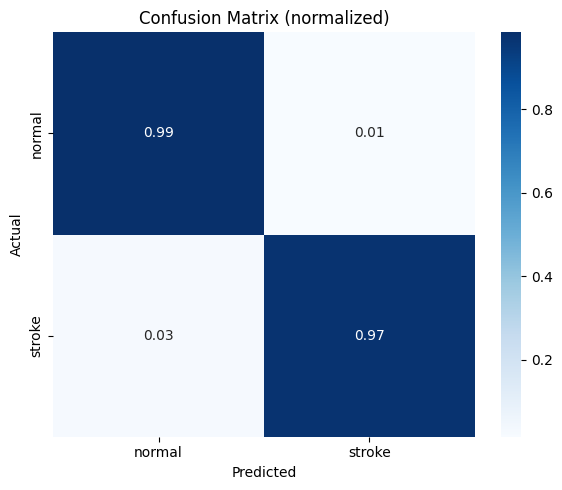

In [10]:
# Cell 8: Evaluation & Confusion Matrix plot
# Load best model (if saved)
if MODEL_SAVE_PATH.exists():
    ckpt = torch.load(MODEL_SAVE_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state"])
    print("Loaded best model from:", MODEL_SAVE_PATH)

model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for imgs, labels in tqdm(val_loader, desc="Evaluating"):
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        
        # ✅ Flatten in case model outputs [B, C, 1, 1]
        outputs = outputs.view(outputs.size(0), -1)

        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# ✅ Convert to numpy arrays just in case
all_preds = np.array(all_preds).astype(int)
all_labels = np.array(all_labels).astype(int)

# Metrics
print("\nClassification Report:")
print(classification_report(
    all_labels, all_preds, 
    target_names=list(train_dataset.classes), 
    zero_division=0
))
print("Overall Accuracy:", accuracy_score(all_labels, all_preds))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]  # normalized by true count

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (counts)")
plt.tight_layout()
plt.show()

# Normalized confusion matrix plot
plt.figure(figsize=(6,5))
sns.heatmap(cm_norm, annot=True, fmt=".2f", xticklabels=train_dataset.classes, yticklabels=train_dataset.classes, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (normalized)")
plt.tight_layout()
plt.show()
